Frame extraction completed


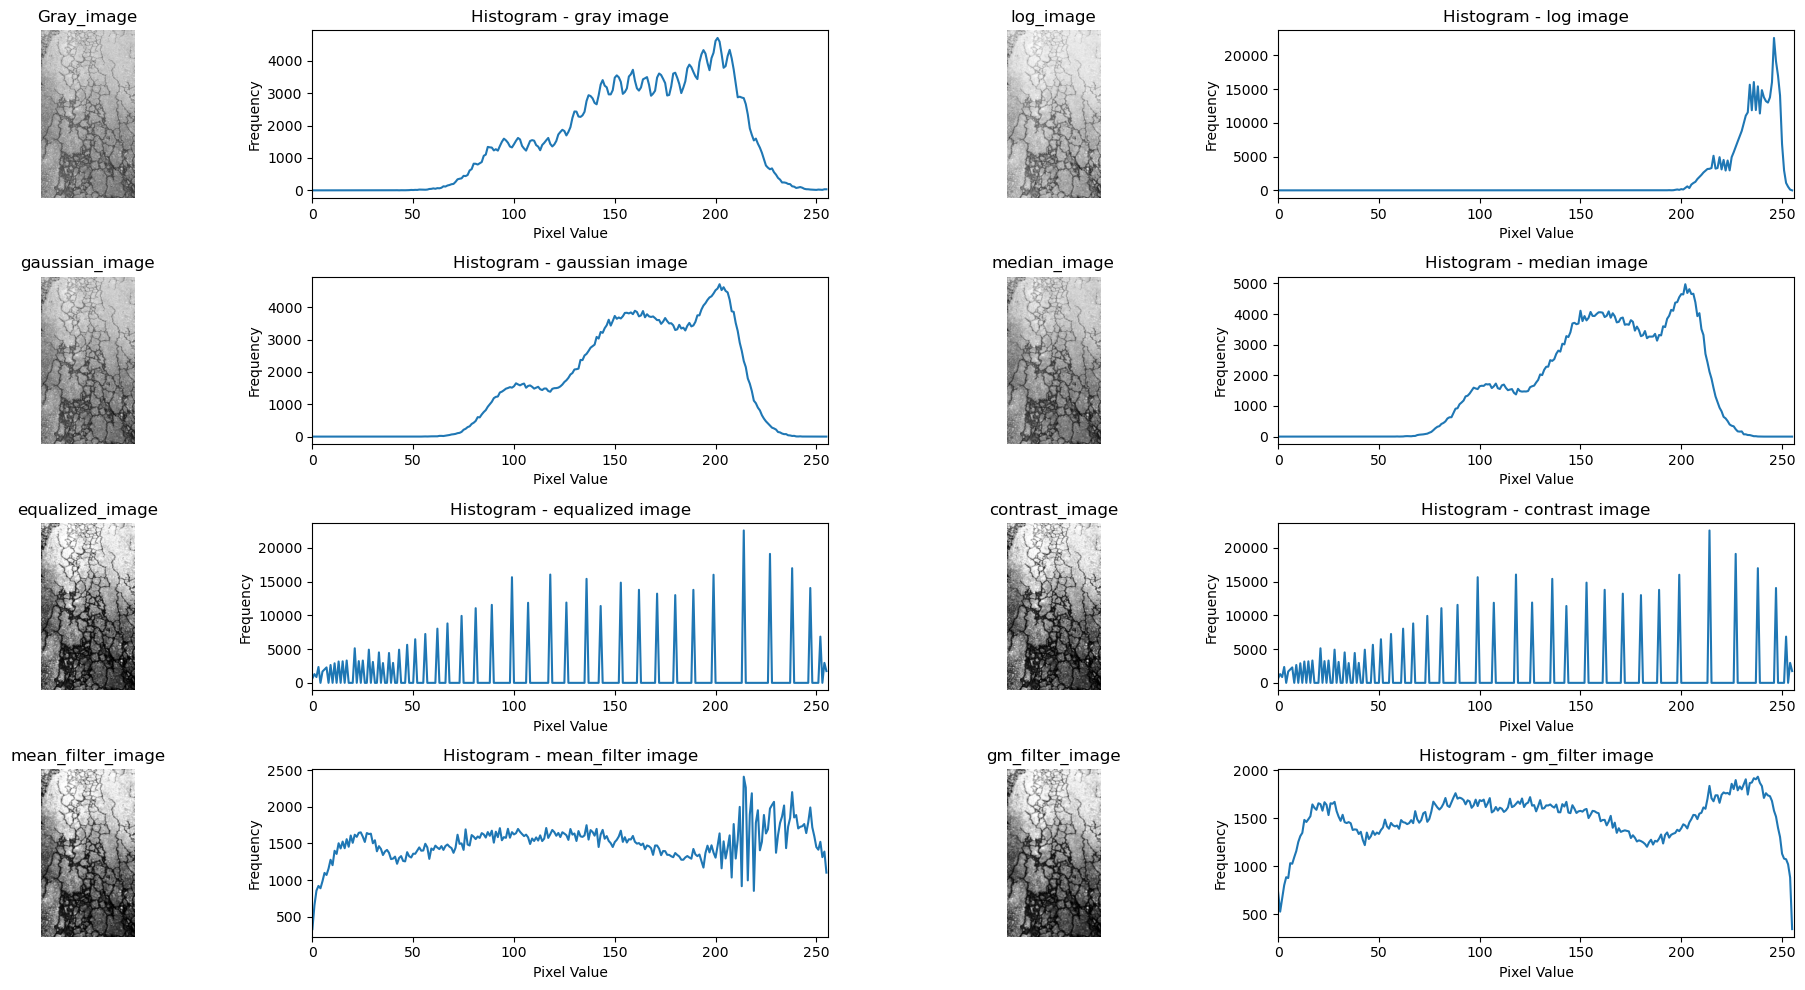

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

video_path = "Videos/Alligator.mp4"
frame_folder = "Frames"
result_folder = "Result"

cap = cv2.VideoCapture(video_path)
count = 0
frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if count % 30 == 0:  
        frame_path = f"{frame_folder}/frame_{frame_id}.jpg"
        cv2.imwrite(frame_path, frame)
        frame_id += 1

    count += 1

cap.release()
print("Frame extraction completed")

def plot_histogram(image, title):
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.plot(histogram)
    plt.xlim([0, 256])


def apply_log_transform(image):
    image = image.astype(np.float32)
    r_max = np.max(image)

    if r_max == 0:
        return image.astype(np.uint8)

    c = 255 / np.log(1 + r_max)
    log_image = c * np.log(1 + image)
    log_image = np.clip(log_image, 0, 255)

    return log_image.astype(np.uint8)


def contrast_stretching(image):
    minval = np.min(image)
    maxval = np.max(image)

    if maxval == minval:
        return image

    dmin, dmax = 0, 255
    stretched = dmin + (image - minval) * ((dmax - dmin) / (maxval - minval))
    return stretched.astype(np.uint8)


def apply_mean_filter(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    return cv2.filter2D(image, -1, kernel)


def apply_geometric_mean_filter(image, kernel_size):
    img_float = image.astype(float)
    pad_size = kernel_size // 2
    padded = np.pad(img_float, pad_size, mode='reflect')
    output = np.zeros_like(image)

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            product = np.prod(region + 1e-5)
            output[i, j] = product ** (1/(kernel_size**2))

    return np.clip(output, 0, 255).astype(np.uint8)

image_path = f"{frame_folder}/frame_30.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Image not found!")
else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gaussian = cv2.GaussianBlur(gray, (3,3), 0)
    median = cv2.medianBlur(gaussian, 3)
    log_img = apply_log_transform(median)
    equalized = cv2.equalizeHist(log_img)
    contrast = contrast_stretching(equalized)
    mean_filter = apply_mean_filter(contrast, 3)
    gm_filter = apply_geometric_mean_filter(mean_filter, 3)
    
    plt.figure(figsize=(20, 10))
    
    plt.subplot(4,4,1)
    plt.imshow(gray,cmap='gray')
    plt.axis("off")
    plt.title("Gray_image")
    
    plt.subplot(4,4,2)
    plot_histogram(gray, "Histogram - gray image")

    plt.subplot(4,4,3)
    plt.imshow(log_img,cmap='gray')
    plt.axis("off")
    plt.title("log_image")
    
    plt.subplot(4,4,4)
    plot_histogram(log_img, "Histogram - log image")

    plt.subplot(4,4,5)
    plt.imshow(gaussian,cmap='gray')
    plt.axis("off")
    plt.title("gaussian_image")
    
    plt.subplot(4,4,6)
    plot_histogram(gaussian, "Histogram - gaussian image")

    plt.subplot(4,4,7)
    plt.imshow(median,cmap='gray')
    plt.axis("off")
    plt.title("median_image")
    
    plt.subplot(4,4,8)
    plot_histogram(median, "Histogram - median image")

    plt.subplot(4,4,9)
    plt.imshow(equalized,cmap='gray')
    plt.axis("off")
    plt.title("equalized_image")
    
    plt.subplot(4,4,10)
    plot_histogram(equalized, "Histogram - equalized image")

    plt.subplot(4,4,11)
    plt.imshow(contrast,cmap='gray')
    plt.axis("off")
    plt.title("contrast_image")
    
    plt.subplot(4,4,12)
    plot_histogram(contrast, "Histogram - contrast image")

    plt.subplot(4,4,13)
    plt.imshow(mean_filter,cmap='gray')
    plt.axis("off")
    plt.title("mean_filter_image")
    
    plt.subplot(4,4,14)
    plot_histogram(mean_filter, "Histogram - mean_filter image")

    plt.subplot(4,4,15)
    plt.imshow(gm_filter,cmap='gray')
    plt.axis("off")
    plt.title("gm_filter_image")
    
    plt.subplot(4,4,16)
    plot_histogram(gm_filter, "Histogram - gm_filter image")
    

    plt.tight_layout()
    plt.show()

    cv2.imwrite(f"{result_folder}/gray.jpg", gray)
    cv2.imwrite(f"{result_folder}/log.jpg", log_img)
    cv2.imwrite(f"{result_folder}/gaussian.jpg", gaussian)
    cv2.imwrite(f"{result_folder}/median.jpg", median)
    cv2.imwrite(f"{result_folder}/equalized.jpg", equalized)
    cv2.imwrite(f"{result_folder}/contrast.jpg", contrast)
    cv2.imwrite(f"{result_folder}/mean.jpg", mean_filter)
    cv2.imwrite(f"{result_folder}/geometric_mean.jpg", gm_filter)
